In [1]:
list_of_packages <- c("ggplot2", "dplyr", "tidyr", "circlize")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                package,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}

plot_theme <- theme_bw() + theme(
        axis.text = element_text(size = 14),
        axis.title = element_text(size = 16),
        legend.text = element_text(size = 14),
        legend.title = element_text(size = 16),
        strip.text = element_text(size = 14),
        plot.title = element_text(size = 18, hjust = 0.5)
    )
# set the color pallete
color_palette <- c(
    "Echo" = "#1AFF1A",
    "CQ1" = "#4B0092"
)

In [2]:

figures_2D_path <- file.path("../figures/microscope_comparisons_2D")
figures_3D_path <- file.path("../figures/microscope_comparisons_3D")
if (!dir.exists(figures_2D_path)) {
  dir.create(figures_2D_path, recursive = TRUE)
}
if (!dir.exists(figures_3D_path)) {
  dir.create(figures_3D_path, recursive = TRUE)
}

analysis_2D_file_path = file.path(
    "../results/raw_image_quality_metrics/merged_results_2D.parquet"
)
analysis_3D_file_path = file.path(
    "../results/raw_image_quality_metrics/merged_results_3D.parquet"
)
raw_image_2D_quality_metrics <- arrow::read_parquet(analysis_2D_file_path)
raw_image_3D_quality_metrics <- arrow::read_parquet(analysis_3D_file_path)

raw_image_2D_quality_metrics <- as.data.frame(raw_image_2D_quality_metrics)
raw_image_3D_quality_metrics <- as.data.frame(raw_image_3D_quality_metrics)


In [3]:

# make the compartment a factor
raw_image_2D_quality_metrics$compartment <- factor(
    raw_image_2D_quality_metrics$compartment,
    levels = c("organoid", "nuclei", "cell")
)
raw_image_3D_quality_metrics$compartment <- factor(
    raw_image_3D_quality_metrics$compartment,
    levels = c("organoid", "nuclei", "cell")
)
# if CQ1 in patient then set microscope to CQ1
raw_image_2D_quality_metrics$microscope <- ifelse(
    grepl("CQ1", raw_image_2D_quality_metrics$patient),
    "CQ1", # set to CQ1 if CQ1 in patient
    "Echo" # else set to Echo
)
raw_image_3D_quality_metrics$microscope <- ifelse(
    grepl("CQ1", raw_image_3D_quality_metrics$patient),
    "CQ1", # set to CQ1 if CQ1 in patient
    "Echo" # else set to Echo
)

# filter the data to only include the NF0037_T1 and NF0037_T1_CQ1 patients
raw_image_2D_quality_metrics <- raw_image_2D_quality_metrics %>%
    filter(patient %in% c("NF0037_T1", "NF0037_T1_CQ1"))
raw_image_3D_quality_metrics <- raw_image_3D_quality_metrics %>%
    filter(patient %in% c("NF0037_T1", "NF0037_T1_CQ1"))
# repalce inf values with NA
# drop basicpy rows
raw_image_2D_quality_metrics <- raw_image_2D_quality_metrics %>%
    filter(basicpy_status != "basicpy")
raw_image_3D_quality_metrics <- raw_image_3D_quality_metrics %>%
    filter(basicpy_status != "basicpy")
raw_image_2D_quality_metrics <- raw_image_2D_quality_metrics %>%
    mutate(across(where(is.numeric), ~ ifelse(is.infinite(.), NA, .)))
raw_image_3D_quality_metrics <- raw_image_3D_quality_metrics %>%
    mutate(across(where(is.numeric), ~ ifelse(is.infinite(.), NA, .)))
head(raw_image_2D_quality_metrics)
head(raw_image_3D_quality_metrics)


,patient,well_fov,channel,z_slice,compartment,signal_to_noise_ratio,michelson_contrast,RMS_contrast,basicpy_status,well,WellRow,WellCol,well_position,treatment,dose,unit,microscope
,<chr>,<chr>,<chr>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>
1,NF0037_T1,B10-1,405,0,cell,4.353334,1,0.2254166,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo
2,NF0037_T1,B10-1,405,1,cell,4.357435,1,0.2247598,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo
3,NF0037_T1,B10-1,405,2,cell,4.351886,1,0.2288429,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo
4,NF0037_T1,B10-1,405,3,cell,4.337603,1,0.2247999,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo
5,NF0037_T1,B10-1,405,4,cell,4.330233,1,0.2255369,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo
6,NF0037_T1,B10-1,405,5,cell,4.320591,1,0.2247121,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo


,patient,well_fov,channel,compartment,signal_to_noise_ratio,michelson_contrast,RMS_contrast,basicpy_status,well,WellRow,WellCol,well_position,treatment,dose,unit,microscope
,<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>
1,NF0037_T1,B10-1,405,cell,7.420109,1,1.655292,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo
2,NF0037_T1,B10-1,405,nuclei,12.921635,1,2.438757,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo
3,NF0037_T1,B10-1,405,organoid,6.657191,1,1.266972,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo
4,NF0037_T1,B10-1,488,cell,4.372527,1,3.520288,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo
5,NF0037_T1,B10-1,488,nuclei,5.143565,1,2.422689,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo
6,NF0037_T1,B10-1,488,organoid,4.411208,1,3.418530,raw_image,B10,B,10,B10,Sapanisertib,1,uM,Echo


## 3D metrics

In [4]:
height_3D <- 6
width_3D <- 12

### Signal to noise ratio

Warning message:
“Removed 236 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 236 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 236 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 236 rows containing missing values or values outside the scale range
(`geom_point()`).”


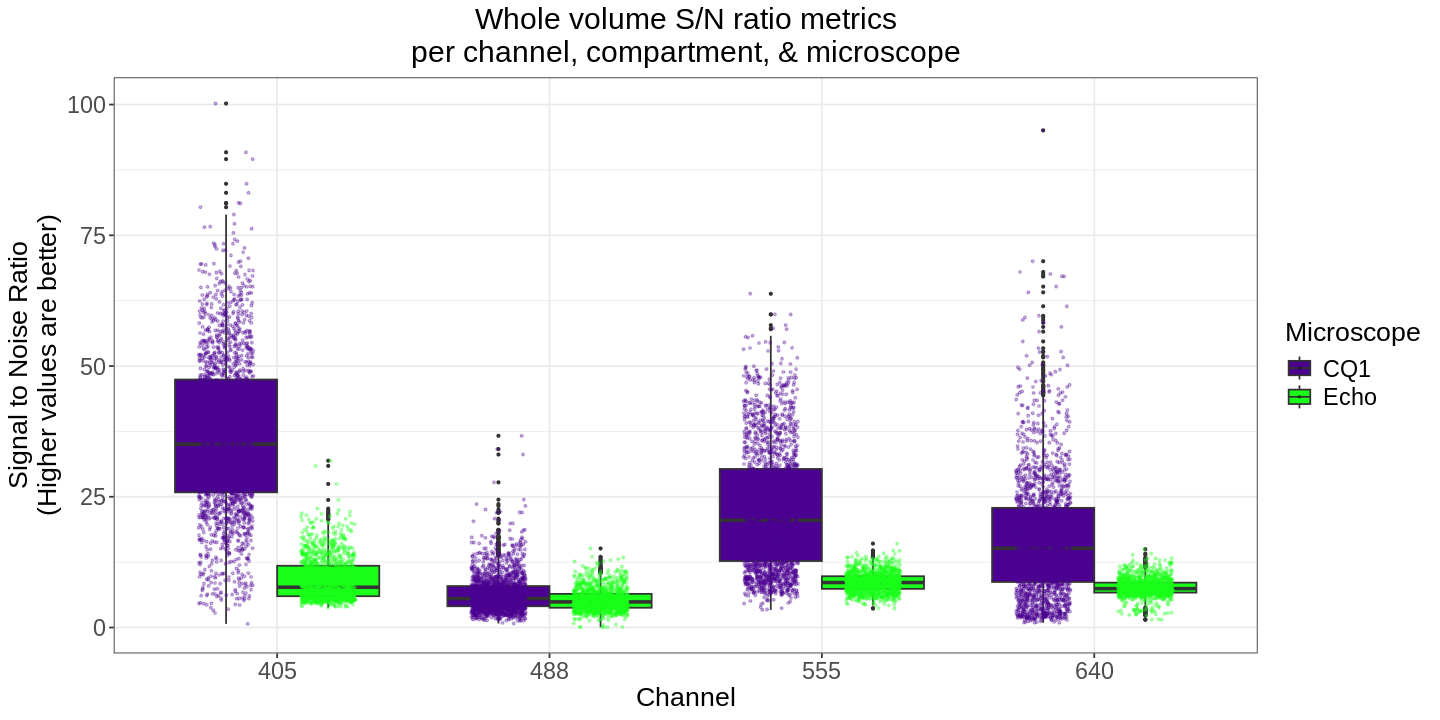

In [5]:
options(repr.plot.width = width_3D, repr.plot.height = height_3D)
s_n_ratio_plot <- (
    ggplot(
        data = raw_image_3D_quality_metrics,
        aes(
            x = channel,
            y = signal_to_noise_ratio,
            fill = microscope
    )
    )
    + geom_boxplot(
        # add jitter and transparency to see all points
        outlier.size = 0.5,
        position = position_dodge(width = 0.75)
    )
    + geom_jitter(
        aes(
            color = microscope
        ),
        position = position_jitterdodge(
            jitter.width = 0.2,
            dodge.width = 0.75
        ),
        alpha = 0.3,
        size = 0.5
    )
    + scale_fill_manual(values = color_palette)
    + scale_color_manual(values = color_palette)
    + labs(
        x = "Channel",
        y = "Signal to Noise Ratio\n(Higher values are better)",
        title = "Whole volume S/N ratio metrics\nper channel, compartment, & microscope"
    )
    + guides(
        fill = guide_legend(
            title = "Microscope"
        ),
        color = "none"
    )
    
    + plot_theme
)
ggsave(
    filename = file.path(
        figures_3D_path,
        "signal_to_noise_ratio_by_microscope_IC_and_channel_3D.png"
    ),
    plot = s_n_ratio_plot,
    width = width_3D,
    height = height_3D,
    units = "in",
    dpi = 600
)
s_n_ratio_plot


### Michelson contrast

Warning message:
“Removed 236 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 236 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 236 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 236 rows containing missing values or values outside the scale range
(`geom_point()`).”


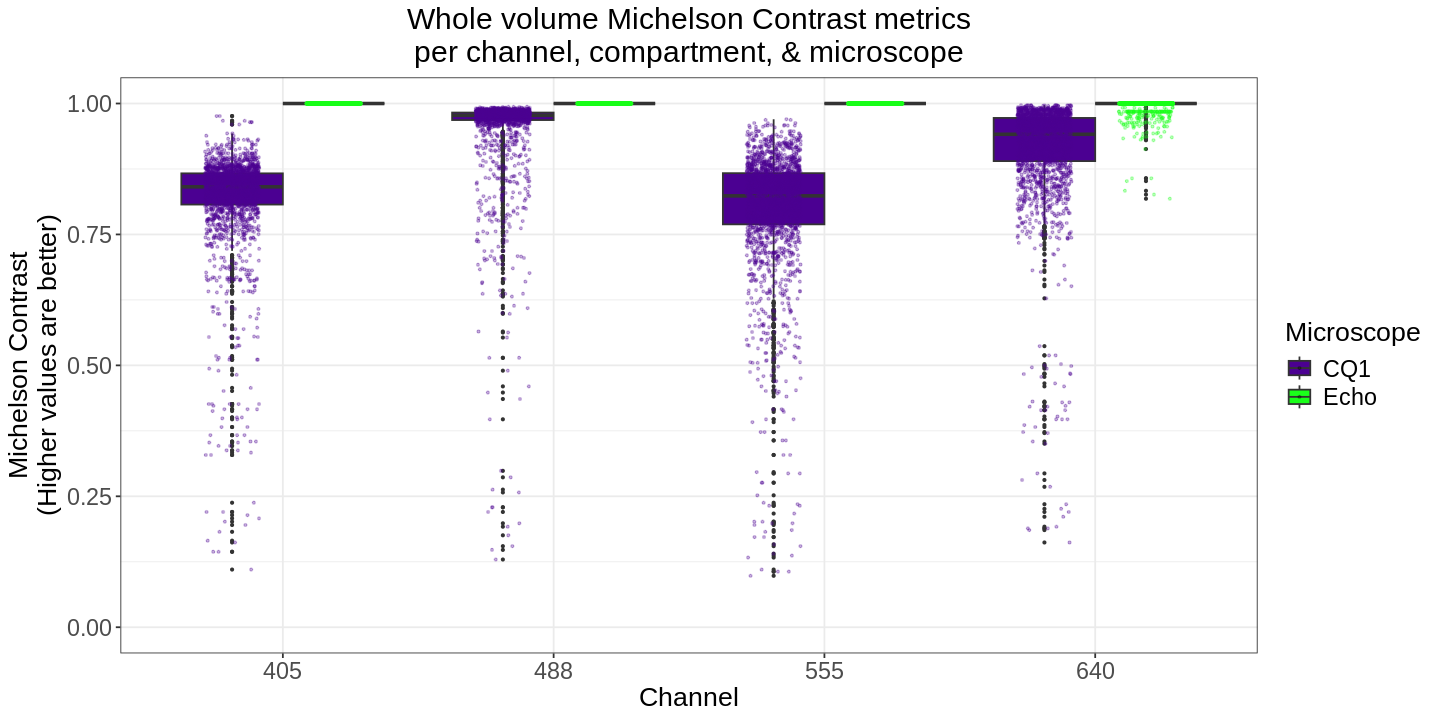

In [6]:
options(repr.plot.width = width_3D, repr.plot.height = height_3D)
michelson_contrast_plot <- (
    ggplot(
        data = raw_image_3D_quality_metrics,
        aes(
            x = channel,
            y = michelson_contrast,
            fill = microscope
    )
    )
    + geom_boxplot(
        # add jitter and transparency to see all points
        outlier.size = 0.5,
        position = position_dodge(width = 0.75)
    )
    + geom_jitter(
        aes(
            color = microscope
        ),
        position = position_jitterdodge(
            jitter.width = 0.2,
            dodge.width = 0.75
        ),
        alpha = 0.3,
        size = 0.5
    )
    + scale_fill_manual(values = color_palette)
    + scale_color_manual(values = color_palette)
    + labs(
        x = "Channel",
        y = "Michelson Contrast\n(Higher values are better)",
        title = "Whole volume Michelson Contrast metrics\nper channel, compartment, & microscope"

    )
    + guides(
        fill = guide_legend(
            title = "Microscope"
        ),
        color = "none"
    )
    + ylim(0,1)
    + plot_theme

)
ggsave(
    filename = file.path(
        figures_3D_path,
        "michelson_contrast_by_microscope_IC_and_channel_3D.png"
    ),
    plot = michelson_contrast_plot,
    width = width_3D,
    height = height_3D,
    units = "in",
    dpi = 600
)
michelson_contrast_plot


### RMS contrast

Warning message:
“Removed 236 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 236 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 236 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 236 rows containing missing values or values outside the scale range
(`geom_point()`).”


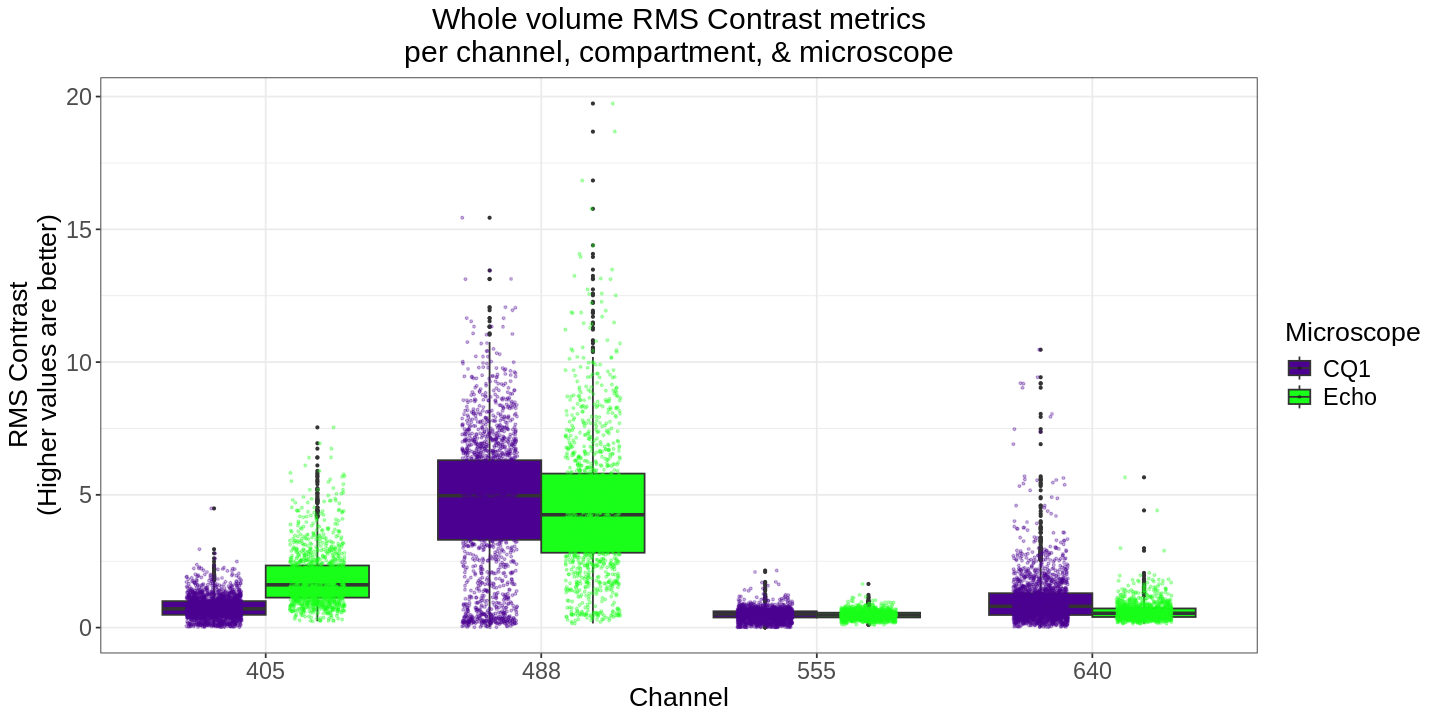

In [7]:
options(repr.plot.width = width_3D, repr.plot.height = height_3D)
RMS_contrast_plot <- (
    ggplot(
        data = raw_image_3D_quality_metrics,
        aes(
            x = channel,
            y = RMS_contrast,
            fill = microscope
    )
    )
    + geom_boxplot(
        # add jitter and transparency to see all points
        outlier.size = 0.5,
        position = position_dodge(width = 0.75)
    )
    + geom_jitter(
        aes(
            color = microscope
        ),
        position = position_jitterdodge(
            jitter.width = 0.2,
            dodge.width = 0.75
        ),
        alpha = 0.3,
        size = 0.5
    )
    + scale_fill_manual(values = color_palette)
    + scale_color_manual(values = color_palette)
    + labs(
        x = "Channel",
        y = "RMS Contrast\n(Higher values are better)",
        title = "Whole volume RMS Contrast metrics\nper channel, compartment, & microscope"

    )
    + guides(
        fill = guide_legend(
            title = "Microscope"
        ),
        color = "none"
    )
    + plot_theme
)
ggsave(
    filename = file.path(
        figures_3D_path,
        "RMS_contrast_by_microscope_IC_and_channel_3D.png"
    ),
    plot = RMS_contrast_plot,
    width = width_3D,
    height = height_3D,
    units = "in",
    dpi = 600
)
RMS_contrast_plot


## 2D metrics

In [8]:
width_2D <- 12
height_2D <- 12
x_axis_label <- "Z-slice depth\n(Normalized per FOV to 0-1 scale)"

In [9]:

# normalize the per channel per microscope per well fov the z slice values
# to be between 0 and 1 for each channel and microscope combination
raw_image_2D_quality_metrics <- raw_image_2D_quality_metrics %>%
    group_by(patient, microscope, channel, well_fov) %>%
    mutate(
        z_slice_normalized = (z_slice - min(z_slice)) / (max(z_slice) - min(z_slice))
    ) %>%
    ungroup()
# randomize the row order to avoid plotting one condition on top of the other
raw_image_2D_quality_metrics <- raw_image_2D_quality_metrics %>%
    group_by(patient) %>%
    sample_frac(1) %>%
    ungroup()
head(raw_image_2D_quality_metrics)


patient,well_fov,channel,z_slice,compartment,signal_to_noise_ratio,michelson_contrast,RMS_contrast,basicpy_status,well,WellRow,WellCol,well_position,treatment,dose,unit,microscope,z_slice_normalized
<chr>,<chr>,<chr>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>
NF0037_T1,C6-5,405,30,organoid,3.659549,1,0.2735597,raw_image,C6,C,6,C6,Imatinib,1,uM,Echo,0.3000000
NF0037_T1,E7-7,488,98,nuclei,NA,NA,NA,raw_image,E7,E,7,E7,Cabozantinib,1,uM,Echo,0.9800000
NF0037_T1,B3-4,555,42,organoid,5.909719,1,0.2105474,raw_image,B3,B,3,B3,ARV-825,1,uM,Echo,0.6774194
NF0037_T1,B11-1,640,0,nuclei,NA,NA,NA,raw_image,B11,B,11,B11,Sapanisertib,1,uM,Echo,0.0000000
NF0037_T1,D6-5,640,36,nuclei,NA,NA,NA,raw_image,D6,D,6,D6,Imatinib,1,uM,Echo,0.3636364
NF0037_T1,D5-2,640,86,cell,5.944336,1,0.1682127,raw_image,D5,D,5,D5,Fimepinostat,1,uM,Echo,0.8686869


### Signal to noise ratio

Warning message:
“Removed 103353 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 103353 rows containing missing values or values outside the scale range
(`geom_line()`).”


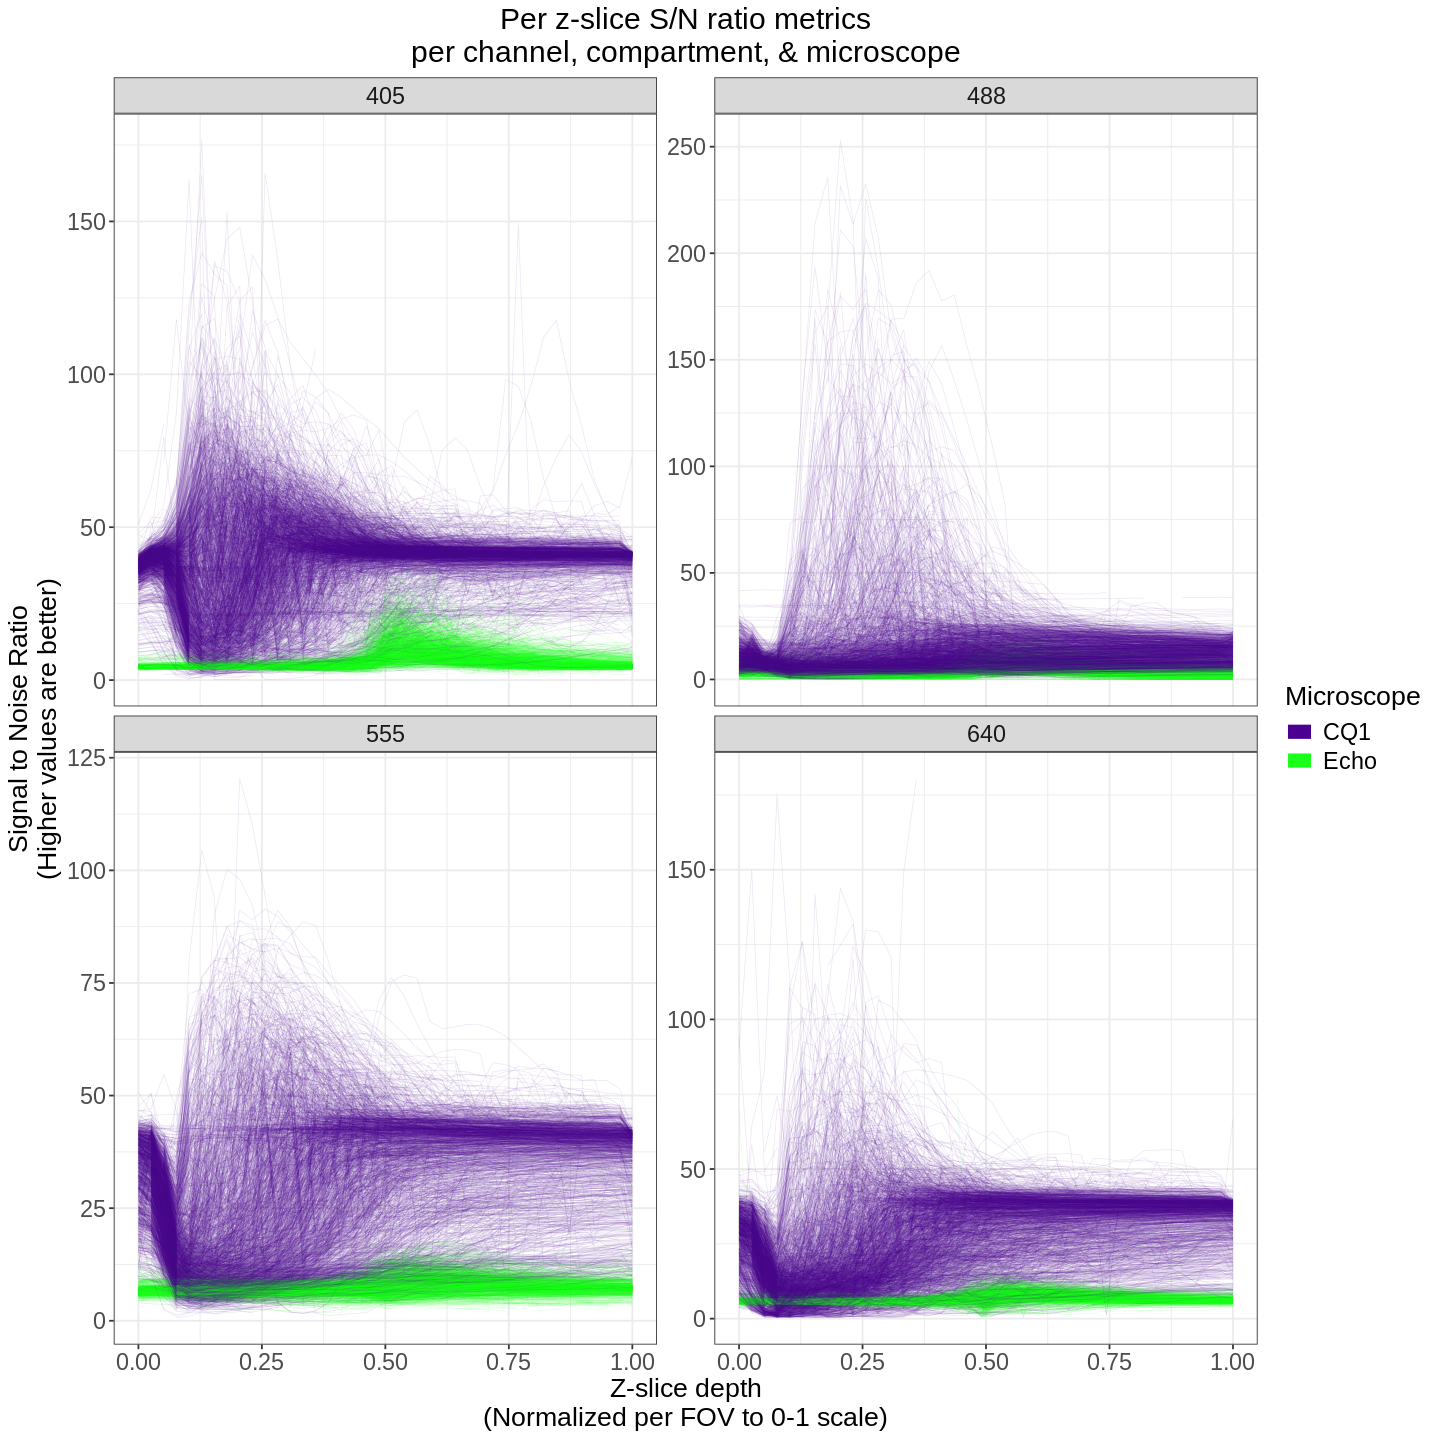

In [10]:
options(repr.plot.width = width_2D, repr.plot.height = height_2D)
s_n_ratio_plot <- (
    ggplot(
        data = raw_image_2D_quality_metrics,
        aes(
            x = z_slice_normalized,
            y = signal_to_noise_ratio,
            color = microscope
    )
    )
    + geom_line(
        aes(group = interaction(well_fov, patient, channel,compartment, basicpy_status)),
        alpha = 0.1,
        linewidth = 0.2
    )
    + scale_color_manual(values = color_palette)
    + labs(
        x = x_axis_label,
        y = "Signal to Noise Ratio\n(Higher values are better)",
        title = "Per z-slice S/N ratio metrics\nper channel, compartment, & microscope"

    )
    + facet_wrap(channel ~ ., scales = "free_y", ncol = 2)
    + guides(
        color = guide_legend(
            title = "Microscope", override.aes = list(
                linewidth = 4,
                alpha = 1
            )
        ),
        text = element_text(size = 16)
    )
    + theme(
        axis.text = element_text(size = 14),
        axis.title = element_text(size = 16),
        legend.text = element_text(size = 14),
        legend.title = element_text(size = 16),
        strip.text = element_text(size = 14)
    )
    + plot_theme
)
ggsave(
    filename = file.path(
        figures_2D_path,
        "signal_to_noise_ratio_by_microscope_IC_and_channel_2D.png"
    ),
    plot = s_n_ratio_plot,
    width = width_2D,
    height = height_2D,
    units = "in",
    dpi = 600
)
s_n_ratio_plot


### Michelson contrast

Warning message:
“Removed 103374 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 103374 rows containing missing values or values outside the scale range
(`geom_line()`).”


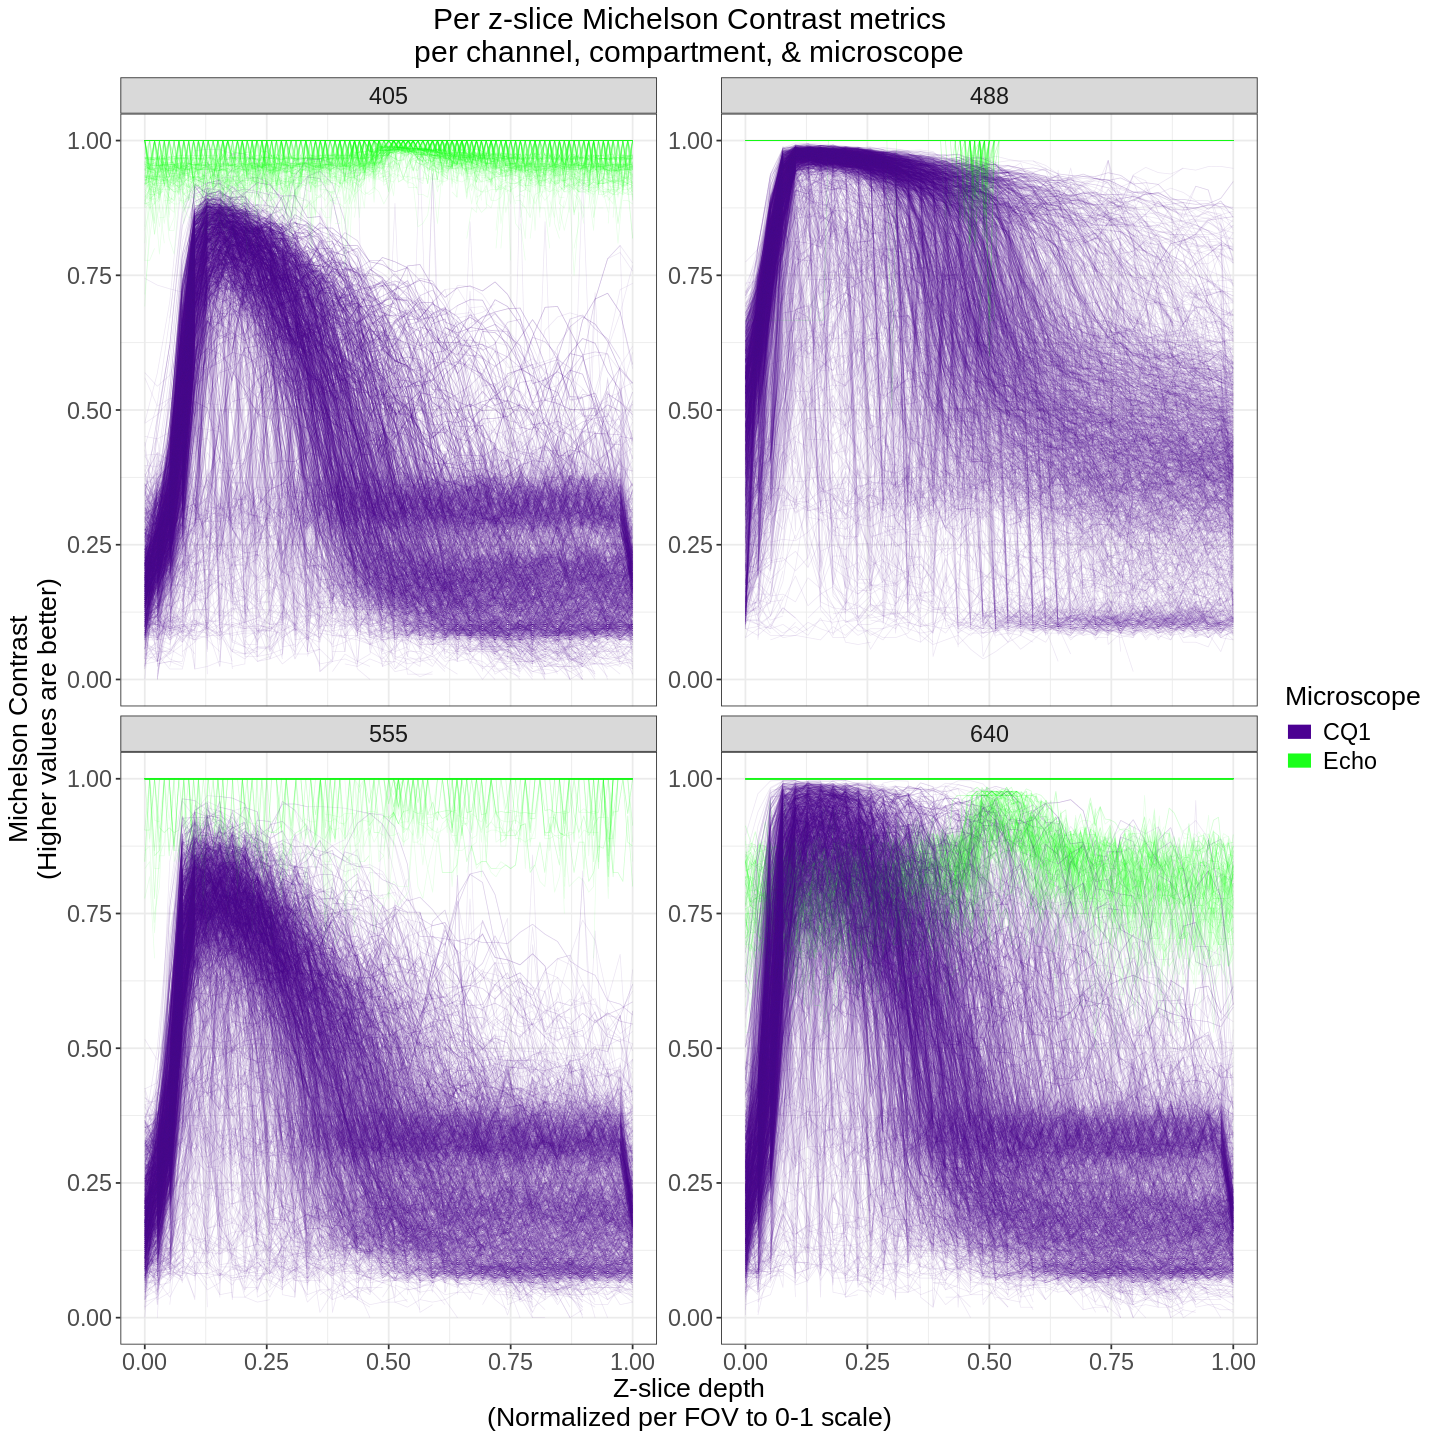

In [11]:
options(repr.plot.width = width_2D, repr.plot.height = height_2D)
michelson_contrast_plot <- (
    ggplot(
        data = raw_image_2D_quality_metrics,
        aes(
            x = z_slice_normalized,
            y = michelson_contrast,
            color = microscope
    )
    )
    + geom_line(
        aes(group = interaction(well_fov, patient, channel,compartment, basicpy_status)),
        alpha = 0.1,
        linewidth = 0.2
    )
    + scale_color_manual(values = color_palette)
    + labs(
        x = x_axis_label,
        y = "Michelson Contrast\n(Higher values are better)",
        title = "Per z-slice Michelson Contrast metrics\nper channel, compartment, & microscope"
    )
    + ylim(0,1)
    + facet_wrap(channel ~ ., scales = "free_y", ncol = 2)
    + guides(
        color = guide_legend(
            title = "Microscope", override.aes = list(
                linewidth = 4,
                alpha = 1
            )
        )
    )
    + plot_theme

)
ggsave(
    filename = file.path(
        figures_2D_path,
        "michelson_contrast_by_microscope_IC_and_channel_2D.png"
    ),
    plot = michelson_contrast_plot,
    width = width_2D,
    height = height_2D,
    units = "in",
    dpi = 600
)
michelson_contrast_plot


### RMS contrast

Warning message:
“Removed 103353 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 103353 rows containing missing values or values outside the scale range
(`geom_line()`).”


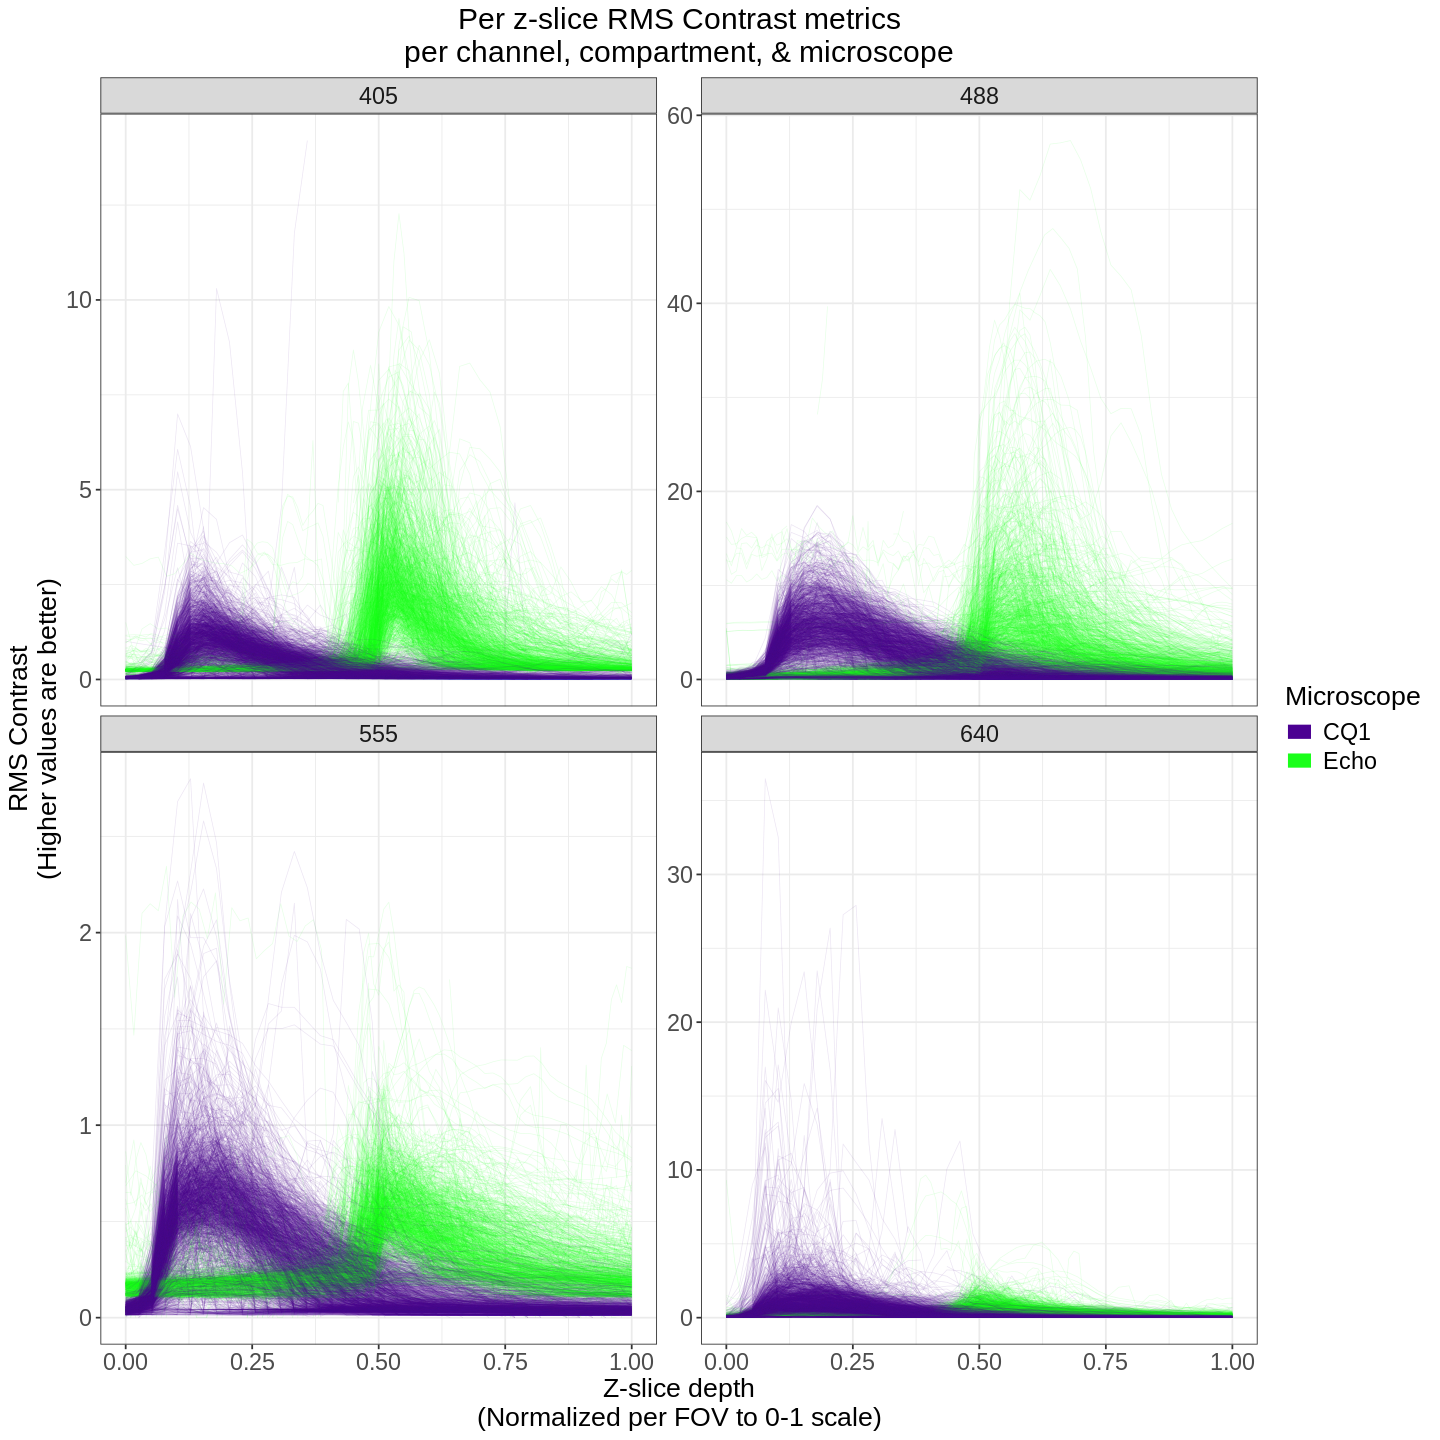

In [12]:
options(repr.plot.width = width_2D, repr.plot.height = height_2D)
RMS_contrast_plot <- (
    ggplot(
        data = raw_image_2D_quality_metrics,
        aes(
            x = z_slice_normalized,
            y = RMS_contrast,
            color = microscope
    )
    )
    + geom_line(
        aes(group = interaction(well_fov, patient, channel,compartment, basicpy_status)),
        alpha = 0.1,
        linewidth = 0.2
    )
    + scale_color_manual(values = color_palette)
    + labs(
        x = x_axis_label,
        y = "RMS Contrast\n(Higher values are better)",
        title = "Per z-slice RMS Contrast metrics\nper channel, compartment, & microscope"
    )
    + facet_wrap(channel ~ ., scales = "free_y", ncol = 2)
    + guides(
        color = guide_legend(
            title = "Microscope", override.aes = list(
                linewidth = 4,
                alpha = 1
            )
        )
    )
    + plot_theme

)
ggsave(
    filename = file.path(
        figures_2D_path,
        "RMS_contrast_by_microscope_IC_and_channel_2D.png"
    ),
    plot = RMS_contrast_plot,
    width = width_2D,
    height = height_2D,
    units = "in",
    dpi = 600
)
RMS_contrast_plot